In [67]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression


**Data Extraction**

In [68]:
data = r'D:\Phone addicted\Smartphone-Addiction-Warning-System-Rebuild-\data\Preprocessed Data\preprocessed_data.csv'
df = pd.read_csv(data)
df

,Age,Gender,Daily_Usage_Hours,Addiction_Level,Tracked_Hours,Untracked_Hours,Leisure_Hours,Leisure_Ratio,Education_Ratio,Social_vs_Gaming,...,Offline_Activity,Online_To_Offline_Ratio,Family_To_Screen_Ratio,Anxiety_Level_z,Depression_Level_z,Self_Esteem_z,Distress_Index,Academic_Per_Usage,Unsupervised_Usage,Grade_Num
0,13,0,4.0,10.0,6.500000,-2.500000,5.300000,1.325000,0.300000,1.900000,...,5.100000,0.784314,1.000000,1.525594,-0.856794,0.857699,-0.523299,19.500000,1.970667,9
1,17,0,5.5,10.0,6.900000,-1.400000,5.100000,0.927273,0.327273,-2.900000,...,6.040667,0.910496,0.363636,-0.895984,0.536178,-0.890092,0.710189,12.727273,2.709667,7
2,13,2,5.8,9.2,2.200000,3.600000,1.800000,0.310345,0.068966,-1.200000,...,8.800000,0.659091,1.034483,-1.241923,-0.856794,1.556816,-2.606174,16.034483,2.857467,11
3,18,0,3.1,9.8,5.500000,-2.400000,4.700000,1.516129,0.258065,1.500000,...,9.600000,0.322917,2.580645,1.179654,1.580908,-0.890092,2.270372,25.161290,1.527267,12
4,14,2,2.5,8.6,4.600000,-2.100000,3.500000,1.400000,0.440000,1.700000,...,5.100000,0.490196,4.000000,-1.587863,-0.160308,-1.589208,0.715123,22.400000,1.231667,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,16,0,3.9,9.8,5.500000,-1.600000,4.500000,1.153846,0.256410,0.900000,...,4.900000,0.795918,2.051282,0.487775,1.580908,-1.239650,2.273991,13.589744,0.000000,12
2996,13,0,3.6,5.5,4.925267,-1.325267,4.625267,1.284796,0.083333,1.574733,...,6.040667,0.595961,2.500000,0.833714,0.884421,1.207257,-0.348189,25.833333,0.000000,8
2997,14,2,3.2,6.2,5.000000,-1.800000,2.600000,0.812500,0.750000,2.200000,...,2.040667,1.568115,2.812500,-0.550044,-0.856794,1.207257,-1.910676,30.625000,1.576533,7
2998,17,0,6.7,10.0,5.800000,0.900000,4.300000,0.641791,0.223881,-0.900000,...,3.200000,2.093750,0.597015,-0.895984,-0.160308,1.207257,-1.735403,10.000000,3.300867,9


In [69]:
df.shape

(3000, 28)

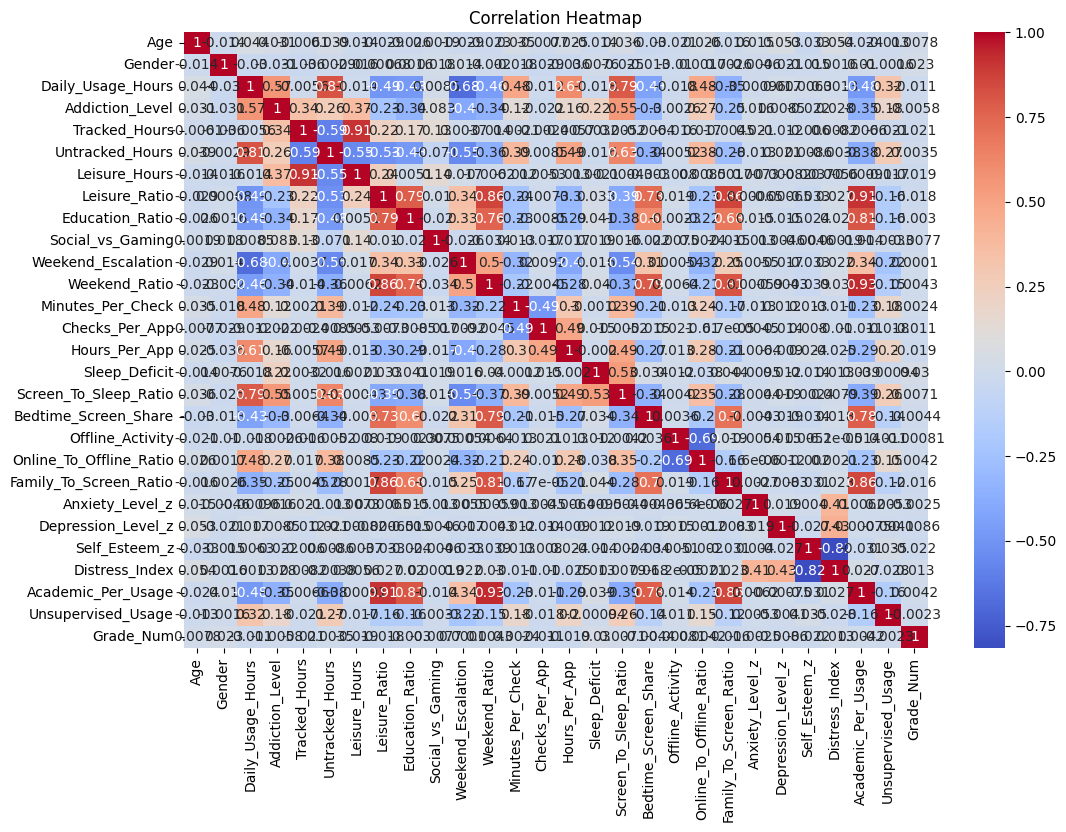

In [70]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Feature Selection**

In [71]:
df.columns

Index(['Age', 'Gender', 'Daily_Usage_Hours', 'Addiction_Level',
       'Tracked_Hours', 'Untracked_Hours', 'Leisure_Hours', 'Leisure_Ratio',
       'Education_Ratio', 'Social_vs_Gaming', 'Weekend_Escalation',
       'Weekend_Ratio', 'Minutes_Per_Check', 'Checks_Per_App', 'Hours_Per_App',
       'Sleep_Deficit', 'Screen_To_Sleep_Ratio', 'Bedtime_Screen_Share',
       'Offline_Activity', 'Online_To_Offline_Ratio', 'Family_To_Screen_Ratio',
       'Anxiety_Level_z', 'Depression_Level_z', 'Self_Esteem_z',
       'Distress_Index', 'Academic_Per_Usage', 'Unsupervised_Usage',
       'Grade_Num'],
      dtype='object')

In [72]:
X = df.drop('Addiction_Level', axis=1)
Y = df['Addiction_Level']
selector = SelectKBest(f_regression, k=18).set_output(transform='pandas')
X_new = selector.fit_transform(X, Y)
X_new.columns

Index(['Daily_Usage_Hours', 'Tracked_Hours', 'Untracked_Hours',
       'Leisure_Hours', 'Leisure_Ratio', 'Education_Ratio', 'Social_vs_Gaming',
       'Weekend_Escalation', 'Weekend_Ratio', 'Minutes_Per_Check',
       'Hours_Per_App', 'Sleep_Deficit', 'Screen_To_Sleep_Ratio',
       'Bedtime_Screen_Share', 'Online_To_Offline_Ratio',
       'Family_To_Screen_Ratio', 'Academic_Per_Usage', 'Unsupervised_Usage'],
      dtype='object')

In [73]:
S = StandardScaler()
X_scaled = S.fit_transform(X_new)
print(X_scaled)

[[-0.55884128  0.90147131 -0.98052299 ... -0.16232732  0.01172471
   0.52651092]
 [ 0.23010699  1.18930865 -0.51466737 ... -0.40385633 -0.26621013
   1.0516203 ]
 [ 0.38789664 -2.19278009  1.60285816 ... -0.14923954 -0.13049096
   1.15664217]
 ...
 [-0.97961368 -0.17791871 -0.68406941 ...  0.52559907  0.46826533
   0.24645258]
 [ 0.8612656   0.39775597  0.45939437 ... -0.31527853 -0.3781302
   1.4717078 ]
 [-0.82182403 -0.25042973 -0.51434268 ...  0.21721827  0.13776803
  -0.87378076]]


In [74]:
X_new_train, X_new_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)
X_new_train.shape, X_new_test.shape, Y_train.shape, Y_test.shape

((2400, 18), (600, 18), (2400,), (600,))

**Single Model**

In [75]:
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.metrics import mean_squared_error, r2_score
models = {
    'lr' : LinearRegression(),
    'rid' : Ridge(),
    'las' : Lasso()
}
for model in models:
    models[model].fit(X_new_train, Y_train)
    y_pred = models[model].predict(X_new_test)
    print(f"{model} : ")
    print(f"Mean Squared Error: {mean_squared_error(Y_test, y_pred)}")
    print(f"R2 Score: {r2_score(Y_test, y_pred):.2f}")


lr : 
Mean Squared Error: 0.9645394014470772
R2 Score: 0.62
rid : 
Mean Squared Error: 0.9638310465556663
R2 Score: 0.62
las : 
Mean Squared Error: 2.5193170572916666
R2 Score: -0.00


In [83]:
from sklearn.model_selection import GridSearchCV
lr_params = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'n_jobs': [None, -1],
    'positive': [True, False]
    }
rid_params = {
    'alpha': [0.1, 1.0, 10.0],
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'max_iter': [None, 1000, 5000],
    'tol': [1e-4, 1e-3, 1e-2],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
    'positive': [True, False]}
las_params = {
    'alpha': [0.1, 1.0, 10.0],
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'max_iter': [None, 1000, 5000],
    'tol': [1e-4, 1e-3, 1e-2],
    'selection': ['cyclic', 'random'],
    'positive': [True, False]
}
single_models_hyperparams_search = {
    'lr' : lr_params,
    'rid' : rid_params,
    'las' : las_params}
for j in single_models_hyperparams_search:
    grid_search = GridSearchCV(models[j], single_models_hyperparams_search[j], cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_new_train, Y_train)
    print(f"{j} : ")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best R2 Score: {grid_search.best_score_:.2f}")

lr : 
Best Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
Best R2 Score: 0.58


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
3240 fits failed out of a total of 7560.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\MSI\AppData\L

rid : 
Best Parameters: {'alpha': 10.0, 'copy_X': False, 'fit_intercept': True, 'max_iter': 1000, 'positive': False, 'solver': 'sag', 'tol': 0.01}
Best R2 Score: 0.59
las : 
Best Parameters: {'alpha': 0.1, 'copy_X': True, 'fit_intercept': True, 'max_iter': 1000, 'positive': False, 'selection': 'random', 'tol': 0.0001}
Best R2 Score: 0.56


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
720 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
720 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\MSI\AppData\Lo

**Ensemble Learning**


In [ ]:
# from sklearn.model_selection import GridSearchCV
# rf_params = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'bootstrap': [True, False]}
# gb_params = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 5, 7],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],}
# xgb_params = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0],}
# hyperparameter_grids = {
#     'rf': rf_params,
#     'gb': gb_params,
#     'xgb': xgb_params}
# for i in hyperparameter_grids:
#     grid_search = GridSearchCV(estimator=ensemble_models[i], param_grid=hyperparameter_grids[i], cv=5, n_jobs=-1, verbose=2)
#     grid_search.fit(X_new_train, Y_train)
#     print(f"Best parameters for {i}: {grid_search.best_params_}")
#     best_model = grid_search.best_estimator_
#     y_pred = best_model.predict(X_new_test)
#     print(f"{i} : ")
#     print(f"Mean Squared Error: {mean_squared_error(Y_test, y_pred)}")
#     print(f"R2 Score: {r2_score(Y_test, y_pred):.2f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters for rf: {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
rf : 
Mean Squared Error: 0.5111102934161212
R2 Score: 0.80
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters for gb: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
gb : 
Mean Squared Error: 0.27979100352551695
R2 Score: 0.89
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for xgb: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
xgb : 
Mean Squared Error: 0.2578387686773065
R2 Score: 0.90


In [80]:
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
ensemble_models = {
    'rf' : RandomForestRegressor(bootstrap=True, max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=100, random_state=42),
    'gb' : GradientBoostingRegressor(learning_rate=0.2, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=300, random_state=42),
    'xgb' : XGBRegressor(colsample_bytree=0.8, learning_rate=0.2, max_depth=3, n_estimators=300, subsample=1.0, random_state=42)
}
for m in ensemble_models:
    ensemble_models[m].fit(X_new_train, Y_train)
    y_pred = ensemble_models[m].predict(X_new_test)
    print(f"{m} : ")
    print(f"Mean Squared Error: {mean_squared_error(Y_test, y_pred)}")
    print(f"R2 Score: {r2_score(Y_test, y_pred):.2f}")

rf : 
Mean Squared Error: 0.5111102934161212
R2 Score: 0.80
gb : 
Mean Squared Error: 0.27979100352551695
R2 Score: 0.89
xgb : 
Mean Squared Error: 0.2578387686773065
R2 Score: 0.90


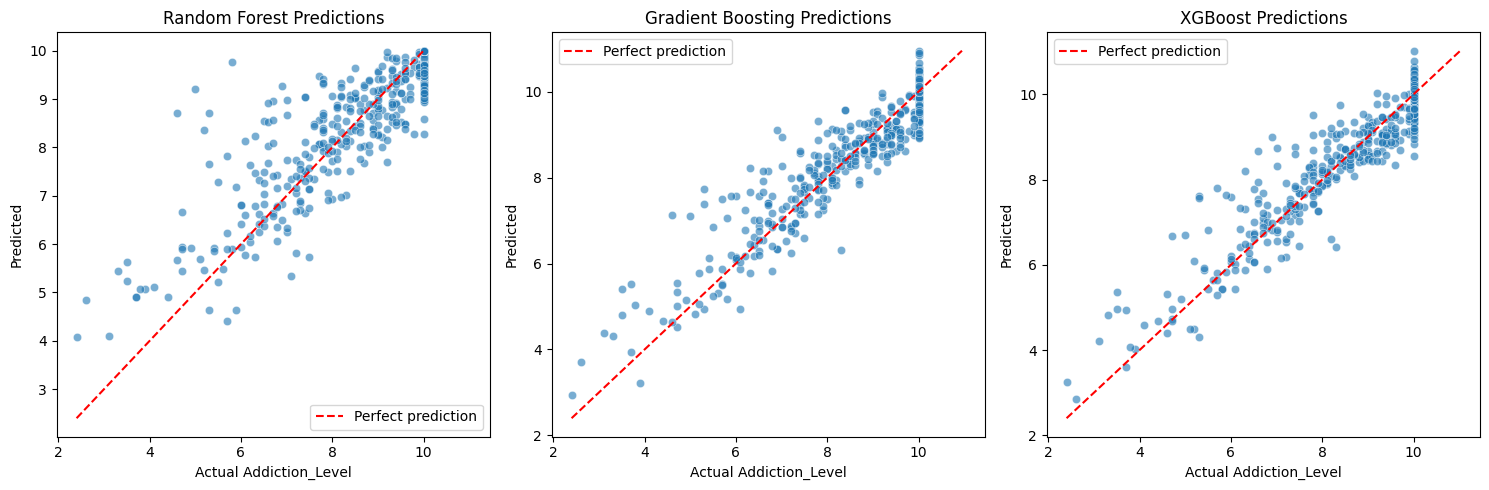

In [85]:
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

preds = {
    'Random Forest': ensemble_models['rf'].predict(X_new_test),
    'Gradient Boosting': ensemble_models['gb'].predict(X_new_test),
    'XGBoost': ensemble_models['xgb'].predict(X_new_test),
}

for a, (name, y_pred) in zip(ax, preds.items()):
    sns.scatterplot(x=Y_test, y=y_pred, ax=a, alpha=0.6)
    lo = min(Y_test.min(), y_pred.min())
    hi = max(Y_test.max(), y_pred.max())
    a.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect prediction')
    a.set_title(f'{name} Predictions')
    a.set_xlabel('Actual Addiction_Level')
    a.set_ylabel('Predicted')
    a.legend()

plt.tight_layout()
plt.show()

In [ ]:
import joblib

# 1. Store your trained model variables in a dictionary
models = {
    'rf_model' : 'rf',
    'gb_model' : 'gb',
    'xgb_model' : 'xgb'
}

# 2. Loop through and save each one independently
for name, model_object in models.items():
    file_name = f"model_{name}.pkl"
    joblib.dump(model_object, file_name)
    print(f"Saved: {file_name}")
